# Movie Recommendation System using Rotten Tomatoes Dataset

## Features
- Data preprocessing
- Exploratory Data Analysis
- NLP with TF-IDF
- Content-based recommendation system
- Interactive movie recommendation interface

In [4]:
!pip install wordcloud
!pip install scikit-learn

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.metrics.pairwise import linear_kernel
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MultiLabelBinarizer, LabelBinarizer, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import linear_kernel
from scipy.sparse import hstack, csr_matrix
from collections import Counter
from wordcloud import WordCloud
from ast import literal_eval

In [12]:
movies = pd.read_csv("rotten_tomatoes_movies.csv")
movies.head()

,id,title,audienceScore,tomatoMeter,rating,ratingContents,releaseDateTheaters,releaseDateStreaming,runtimeMinutes,genre,originalLanguage,director,writer,boxOffice,distributor,soundMix
0,space-zombie-bingo,Space Zombie Bingo!,50.0,NaN,NaN,NaN,NaN,2018-08-25,75.0,"Comedy, Horror, Sci-fi",English,George Ormrod,"George Ormrod,John Sabotta",NaN,NaN,NaN
1,the_green_grass,The Green Grass,NaN,NaN,NaN,NaN,NaN,2020-02-11,114.0,Drama,English,Tiffany Edwards,Tiffany Edwards,NaN,NaN,NaN
2,love_lies,"Love, Lies",43.0,NaN,NaN,NaN,NaN,NaN,120.0,Drama,Korean,"Park Heung-Sik,Heung-Sik Park","Ha Young-Joon,Jeon Yun-su,Song Hye-jin",NaN,NaN,NaN
3,the_sore_losers_1997,Sore Losers,60.0,NaN,NaN,NaN,NaN,2020-10-23,90.0,"Action, Mystery & thriller",English,John Michael McCarthy,John Michael McCarthy,NaN,NaN,NaN
4,dinosaur_island_2002,Dinosaur Island,70.0,NaN,NaN,NaN,NaN,2017-03-27,80.0,"Fantasy, Adventure, Animation",English,Will Meugniot,John Loy,NaN,NaN,NaN


In [18]:
reviews = pd.read_csv("rotten_tomatoes_movie_reviews.csv")
reviews.head()

,id,reviewId,creationDate,criticName,isTopCritic,originalScore,reviewState,publicatioName,reviewText,scoreSentiment,reviewUrl
0,beavers,1145982,2003-05-23,Ivan M. Lincoln,False,3.5/4,fresh,Deseret News (Salt Lake City),Timed to be just long enough for most youngste...,POSITIVE,http://www.deseretnews.com/article/700003233/B...
1,blood_mask,1636744,2007-06-02,The Foywonder,False,1/5,rotten,Dread Central,It doesn't matter if a movie costs 300 million...,NEGATIVE,http://www.dreadcentral.com/index.php?name=Rev...
2,city_hunter_shinjuku_private_eyes,2590987,2019-05-28,Reuben Baron,False,NaN,fresh,CBR,The choreography is so precise and lifelike at...,POSITIVE,https://www.cbr.com/city-hunter-shinjuku-priva...
3,city_hunter_shinjuku_private_eyes,2558908,2019-02-14,Matt Schley,False,2.5/5,rotten,Japan Times,The film's out-of-touch attempts at humor may ...,NEGATIVE,https://www.japantimes.co.jp/culture/2019/02/0...
4,dangerous_men_2015,2504681,2018-08-29,Pat Padua,False,NaN,fresh,DCist,Its clumsy determination is endearing and some...,POSITIVE,http://dcist.com/2015/11/out_of_frame_dangerou...


In [19]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143258 entries, 0 to 143257
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    143258 non-null  object 
 1   title                 142891 non-null  object 
 2   audienceScore         73248 non-null   float64
 3   tomatoMeter           33877 non-null   float64
 4   rating                13991 non-null   object 
 5   ratingContents        13991 non-null   object 
 6   releaseDateTheaters   30773 non-null   object 
 7   releaseDateStreaming  79420 non-null   object 
 8   runtimeMinutes        129431 non-null  float64
 9   genre                 132175 non-null  object 
 10  originalLanguage      129400 non-null  object 
 11  director              139041 non-null  object 
 12  writer                90116 non-null   object 
 13  boxOffice             14743 non-null   object 
 14  distributor           23001 non-null   object 
 15  

In [20]:
missing_value_movies=movies.isna().sum()
print(missing_value_movies)

id                           0
title                      367
audienceScore            70010
tomatoMeter             109381
rating                  129267
ratingContents          129267
releaseDateTheaters     112485
releaseDateStreaming     63838
runtimeMinutes           13827
genre                    11083
originalLanguage         13858
director                  4217
writer                   53142
boxOffice               128515
distributor             120257
soundMix                127341
dtype: int64


In [21]:
movie_percentage = (missing_value_movies / len(movies)) * 100
print(movie_percentage)

id                       0.000000
title                    0.256181
audienceScore           48.869871
tomatoMeter             76.352455
rating                  90.233704
ratingContents          90.233704
releaseDateTheaters     78.519175
releaseDateStreaming    44.561560
runtimeMinutes           9.651817
genre                    7.736392
originalLanguage         9.673456
director                 2.943640
writer                  37.095311
boxOffice               89.708777
distributor             83.944352
soundMix                88.889277
dtype: float64


In [22]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1336431 entries, 0 to 1336430
Data columns (total 11 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   id              1336431 non-null  object
 1   reviewId        1336431 non-null  int64 
 2   creationDate    1336431 non-null  object
 3   criticName      1336431 non-null  object
 4   isTopCritic     1336431 non-null  bool  
 5   originalScore   933893 non-null   object
 6   reviewState     1336431 non-null  object
 7   publicatioName  1336431 non-null  object
 8   reviewText      1272110 non-null  object
 9   scoreSentiment  1336431 non-null  object
 10  reviewUrl       1140812 non-null  object
dtypes: bool(1), int64(1), object(9)
memory usage: 103.2+ MB


In [23]:
missing_value_reviews=reviews.isna().sum()
print(missing_value_reviews)

id                     0
reviewId               0
creationDate           0
criticName             0
isTopCritic            0
originalScore     402538
reviewState            0
publicatioName         0
reviewText         64321
scoreSentiment         0
reviewUrl         195619
dtype: int64


In [24]:
review_percentage = (missing_value_reviews / len(reviews)) * 100
print(review_percentage)

id                 0.000000
reviewId           0.000000
creationDate       0.000000
criticName         0.000000
isTopCritic        0.000000
originalScore     30.120373
reviewState        0.000000
publicatioName     0.000000
reviewText         4.812893
scoreSentiment     0.000000
reviewUrl         14.637419
dtype: float64


In [25]:
#Merging two datasets
movies=pd.merge(left = movies, right = reviews, on = 'id')
movies1 = movies.copy()

In [26]:
movies1 = movies1.drop(columns=['boxOffice', 'soundMix', 'ratingContents', 'rating','distributor','writer','creationDate','reviewUrl','tomatoMeter'])
movies1.head()

,id,title,audienceScore,releaseDateTheaters,releaseDateStreaming,runtimeMinutes,genre,originalLanguage,director,reviewId,criticName,isTopCritic,originalScore,reviewState,publicatioName,reviewText,scoreSentiment
0,love_lies,"Love, Lies",43.0,NaN,NaN,120.0,Drama,Korean,"Park Heung-Sik,Heung-Sik Park",2739073,James Mudge,False,4/5,fresh,easternKicks.com,Though let down by its routine love triangle n...,POSITIVE
1,love_lies,"Love, Lies",43.0,NaN,NaN,120.0,Drama,Korean,"Park Heung-Sik,Heung-Sik Park",2333658,Diva Velez,False,3.5/5,fresh,TheDivaReview.com,"While not perfect, Love, Lies is a worthy disc...",POSITIVE
2,adrift_2018,Adrift,65.0,2018-06-01,2018-08-21,120.0,"Adventure, Drama, Romance",English,Baltasar Kormákur,102694850,Josh Parham,False,6/10,fresh,Next Best Picture,This is nowhere near the level of other great ...,POSITIVE
3,adrift_2018,Adrift,65.0,2018-06-01,2018-08-21,120.0,"Adventure, Drama, Romance",English,Baltasar Kormákur,102654799,Cory Woodroof,False,NaN,fresh,615 Film,"Adrift somehow survives the late reveal, and t...",POSITIVE
4,adrift_2018,Adrift,65.0,2018-06-01,2018-08-21,120.0,"Adventure, Drama, Romance",English,Baltasar Kormákur,2816011,Kip Mooney,False,C+,rotten,College Movie Review,"For almost the entire runtime, the only people...",NEGATIVE


In [27]:
movies1 = movies1.dropna(subset = ['title'])
movies1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1357333 entries, 0 to 1361017
Data columns (total 17 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1357333 non-null  object 
 1   title                 1357333 non-null  object 
 2   audienceScore         1297246 non-null  float64
 3   releaseDateTheaters   1096098 non-null  object 
 4   releaseDateStreaming  1257130 non-null  object 
 5   runtimeMinutes        1334778 non-null  float64
 6   genre                 1340515 non-null  object 
 7   originalLanguage      1334746 non-null  object 
 8   director              1353939 non-null  object 
 9   reviewId              1357333 non-null  int64  
 10  criticName            1357333 non-null  object 
 11  isTopCritic           1357333 non-null  bool   
 12  originalScore         948212 non-null   object 
 13  reviewState           1357333 non-null  object 
 14  publicatioName        1357333 non-null 

In [28]:
#filling the data as unknown
for col in ['genre', 'audienceScore', 'originalLanguage', 'director','originalScore','releaseDateTheaters','releaseDateStreaming','reviewText']:
    movies1[col] = movies1[col].fillna('Unknown')
movies1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1357333 entries, 0 to 1361017
Data columns (total 17 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1357333 non-null  object 
 1   title                 1357333 non-null  object 
 2   audienceScore         1357333 non-null  object 
 3   releaseDateTheaters   1357333 non-null  object 
 4   releaseDateStreaming  1357333 non-null  object 
 5   runtimeMinutes        1334778 non-null  float64
 6   genre                 1357333 non-null  object 
 7   originalLanguage      1357333 non-null  object 
 8   director              1357333 non-null  object 
 9   reviewId              1357333 non-null  int64  
 10  criticName            1357333 non-null  object 
 11  isTopCritic           1357333 non-null  bool   
 12  originalScore         1357333 non-null  object 
 13  reviewState           1357333 non-null  object 
 14  publicatioName        1357333 non-null 

In [29]:
movies1['runtimeMinutes']= movies1['runtimeMinutes'].fillna(movies1['runtimeMinutes'].median())
movies1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1357333 entries, 0 to 1361017
Data columns (total 17 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1357333 non-null  object 
 1   title                 1357333 non-null  object 
 2   audienceScore         1357333 non-null  object 
 3   releaseDateTheaters   1357333 non-null  object 
 4   releaseDateStreaming  1357333 non-null  object 
 5   runtimeMinutes        1357333 non-null  float64
 6   genre                 1357333 non-null  object 
 7   originalLanguage      1357333 non-null  object 
 8   director              1357333 non-null  object 
 9   reviewId              1357333 non-null  int64  
 10  criticName            1357333 non-null  object 
 11  isTopCritic           1357333 non-null  bool   
 12  originalScore         1357333 non-null  object 
 13  reviewState           1357333 non-null  object 
 14  publicatioName        1357333 non-null 

In [30]:
movies1['audienceScore'].dtype
movies1['audienceScore'].unique()

array([43.0, 65.0, 74.0, 'Unknown', 86.0, 60.0, 67.0, 61.0, 75.0, 85.0,
       57.0, 92.0, 83.0, 39.0, 82.0, 38.0, 96.0, 44.0, 41.0, 64.0, 22.0,
       18.0, 76.0, 71.0, 87.0, 42.0, 100.0, 79.0, 56.0, 62.0, 88.0, 69.0,
       52.0, 37.0, 20.0, 80.0, 94.0, 40.0, 25.0, 51.0, 47.0, 13.0, 77.0,
       50.0, 45.0, 73.0, 54.0, 84.0, 34.0, 95.0, 23.0, 48.0, 78.0, 21.0,
       14.0, 24.0, 26.0, 63.0, 32.0, 36.0, 93.0, 68.0, 33.0, 27.0, 58.0,
       17.0, 53.0, 35.0, 0.0, 66.0, 28.0, 15.0, 8.0, 59.0, 11.0, 30.0,
       46.0, 90.0, 70.0, 16.0, 10.0, 31.0, 49.0, 19.0, 72.0, 29.0, 55.0,
       81.0, 7.0, 89.0, 91.0, 98.0, 99.0, 9.0, 12.0, 97.0, 2.0, 6.0, 4.0,
       1.0, 3.0, 5.0], dtype=object)

In [31]:
movies1['audienceScore'] = pd.to_numeric(movies1['audienceScore'], errors = 'coerce')
movies1['audienceScore'] = movies1['audienceScore'].fillna(movies1['audienceScore'].median())

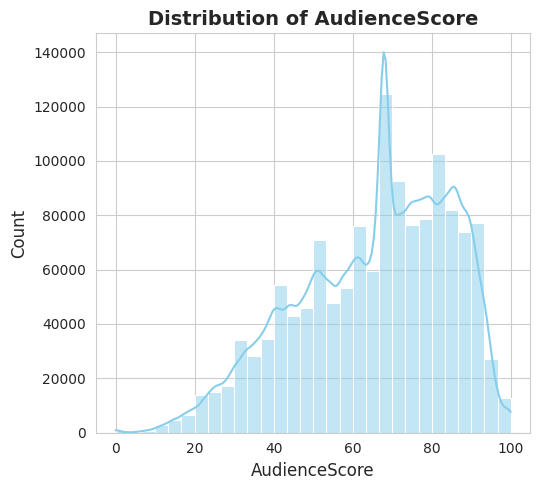

In [32]:
sns.set_style("whitegrid")
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
sns.histplot(movies1['audienceScore'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of AudienceScore', fontsize=14, weight='bold')
plt.xlabel('AudienceScore', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

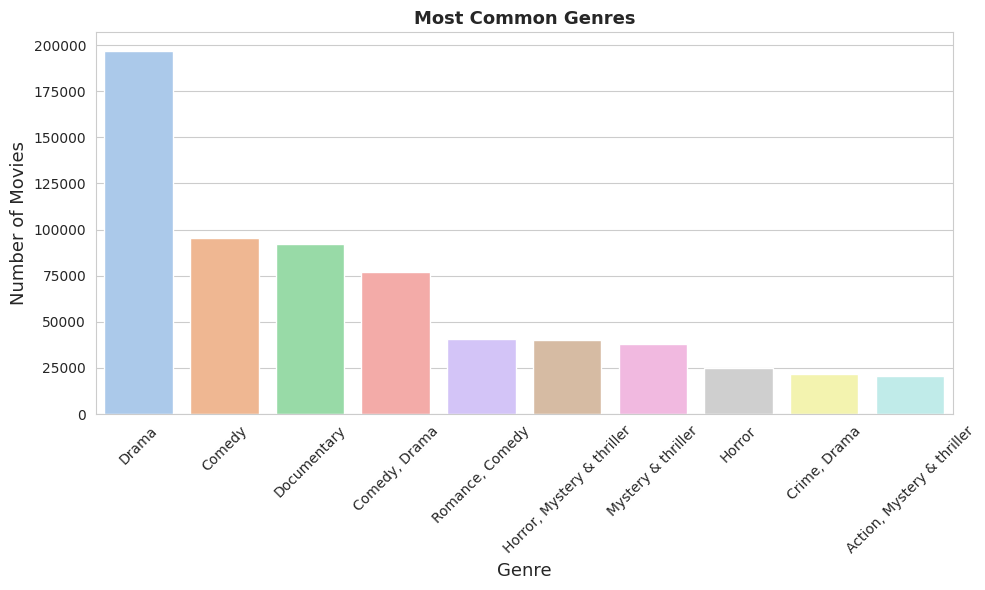

In [33]:
genre_df = (
    movies1['genre']
    .dropna()
    .str.split('|')
    .explode()
    .value_counts()
    .reset_index()
)
genre_df.columns = ['Genre', 'Count']

plt.figure(figsize = (10,6))
sns.barplot(
    data=genre_df.head(10),
    x='Genre',
    y='Count',
    hue='Genre',
    legend=False,
    palette='pastel'
)
plt.title("Most Common Genres", fontsize=13, weight='bold')
plt.xlabel("Genre", fontsize=13)
plt.ylabel("Number of Movies", fontsize=13)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

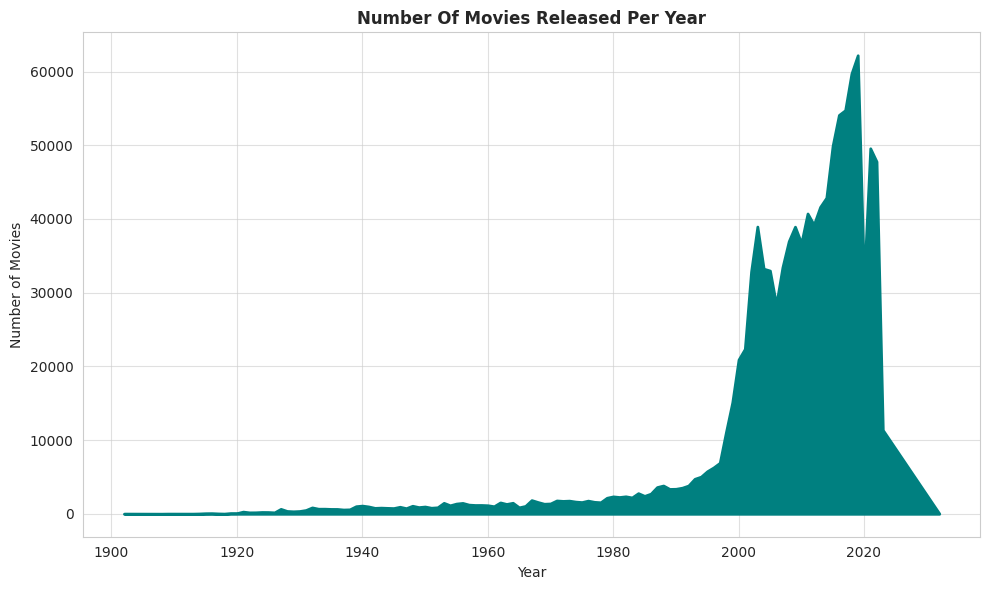

In [35]:
# Convert releaseDateTheaters to datetime
movies1['releaseDateTheaters'] = pd.to_datetime(
    movies1['releaseDateTheaters'],
    errors='coerce',
    format='mixed'
)

# Extract year from releaseDateTheaters
movies1['release_year'] = movies1['releaseDateTheaters'].dt.year
movies_per_year = movies1['release_year'].value_counts().sort_index()

plt.figure(figsize=(10,6))
plt.fill_between(movies_per_year.index, movies_per_year.values, color='teal', linewidth=2)
plt.title("Number Of Movies Released Per Year", fontsize=12, weight='bold')
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.grid(True, linestyle='-', alpha=0.6)
plt.tight_layout()
plt.show()

   release_year  movie_released  avg_audience_score
0        1902.0              14               90.00
1        1908.0               1               67.00
2        1909.0              13               68.00
3        1913.0               9               68.00
4        1914.0              28               50.25


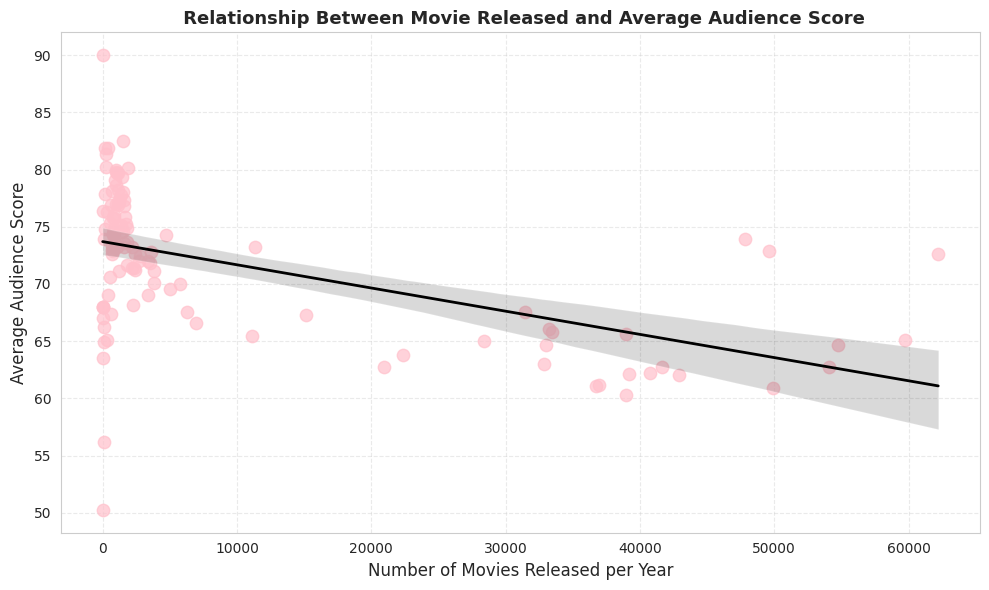

In [36]:
yearly_stat = (movies1.groupby('release_year')
               .agg(movie_released = ('title', 'count'),
                    avg_audience_score = ('audienceScore', 'mean')).reset_index()
               .dropna(subset = ['release_year'])
              )
print(yearly_stat.head())

plt.figure(figsize=(10,6))
sns.regplot(
    data = yearly_stat,
    x = 'movie_released',
    y = 'avg_audience_score',
    scatter_kws = {'color' : 'pink', 's' : 80, 'alpha' : 0.7},
    line_kws ={'color' : 'black', 'lw' : 2}
)

plt.title(" Relationship Between Movie Released and Average Audience Score", fontsize=13, weight='bold')
plt.xlabel("Number of Movies Released per Year", fontsize=12)
plt.ylabel("Average Audience Score", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


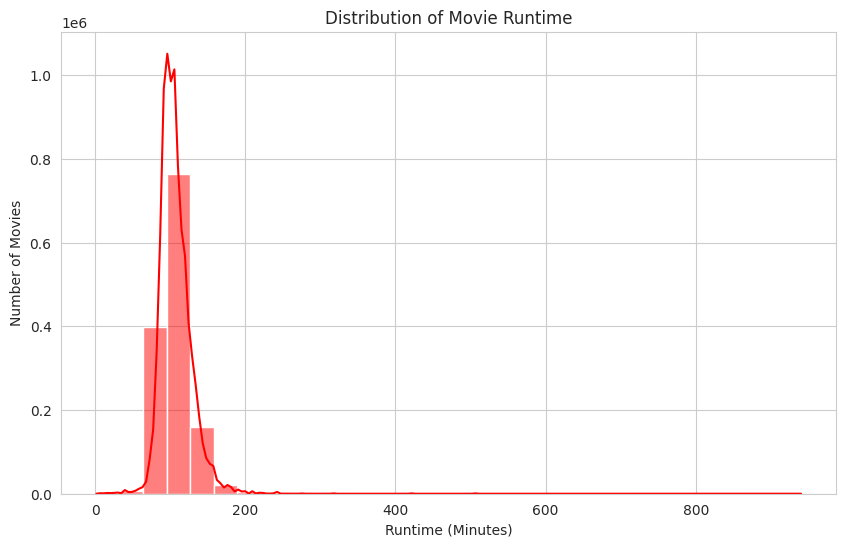

In [37]:
plt.figure(figsize=(10,6))
sns.histplot(movies1['runtimeMinutes'], bins=30, kde=True, color='red')
plt.title("Distribution of Movie Runtime")
plt.xlabel("Runtime (Minutes)")
plt.ylabel("Number of Movies")
plt.show()

In [38]:
movies1.columns

Index(['id', 'title', 'audienceScore', 'releaseDateTheaters',
       'releaseDateStreaming', 'runtimeMinutes', 'genre', 'originalLanguage',
       'director', 'reviewId', 'criticName', 'isTopCritic', 'originalScore',
       'reviewState', 'publicatioName', 'reviewText', 'scoreSentiment',
       'release_year'],
      dtype='object')

<Figure size 1200x720 with 0 Axes>

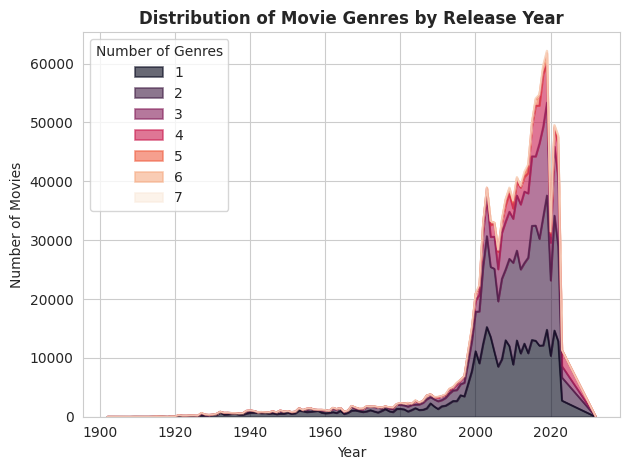

In [39]:
movies1['release_year'] = pd.to_datetime(
    movies1['releaseDateTheaters'], errors='coerce'
).dt.year

movies1['genre_list'] = movies1['genre'].fillna('Unknown').str.split(',')
movies1['num_genres'] = movies1['genre_list'].apply(len)

movies_genre_year = movies1.dropna(subset=['release_year'])
area_data = movies_genre_year.pivot_table(
    index='release_year',
    columns='num_genres',
    aggfunc='size',
    fill_value=0
)

sns.set_style("whitegrid")
plt.figure(figsize=(10,6), dpi=120)
area_data.plot.area(
    cmap=sns.color_palette("rocket", as_cmap=True),
    alpha=0.6, linewidth=1.2)
plt.title("Distribution of Movie Genres by Release Year", fontsize=12, weight='bold')
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.legend(title='Number of Genres', loc='upper left')
plt.tight_layout()
plt.show()

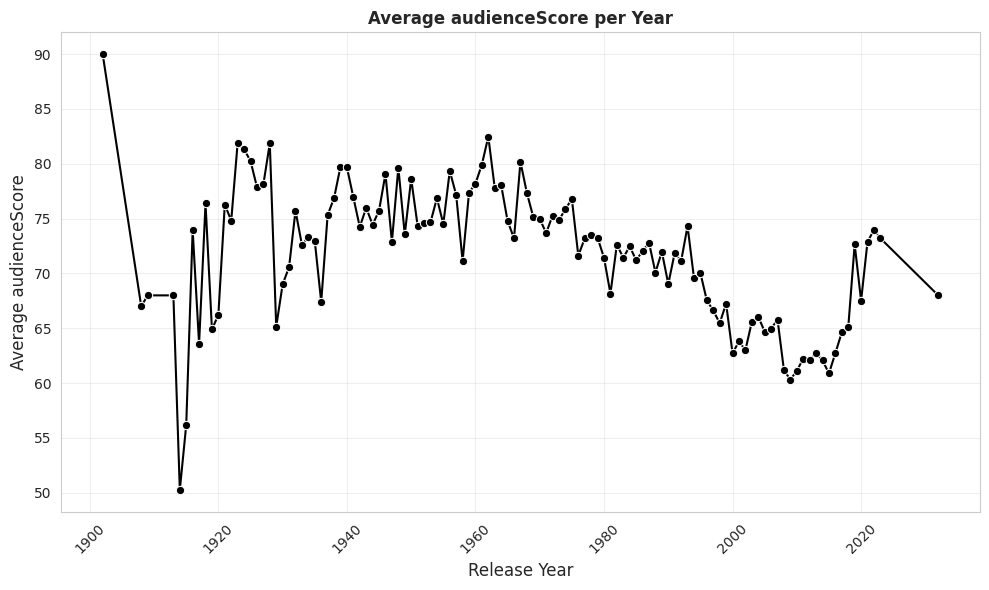

In [40]:
ratings_per_year = movies1.groupby('release_year')['audienceScore'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=ratings_per_year, x='release_year', y='audienceScore', marker='o', color='black')
plt.title("Average audienceScore per Year", fontsize=12, weight='bold')
plt.xlabel("Release Year", fontsize=12)
plt.ylabel("Average audienceScore", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

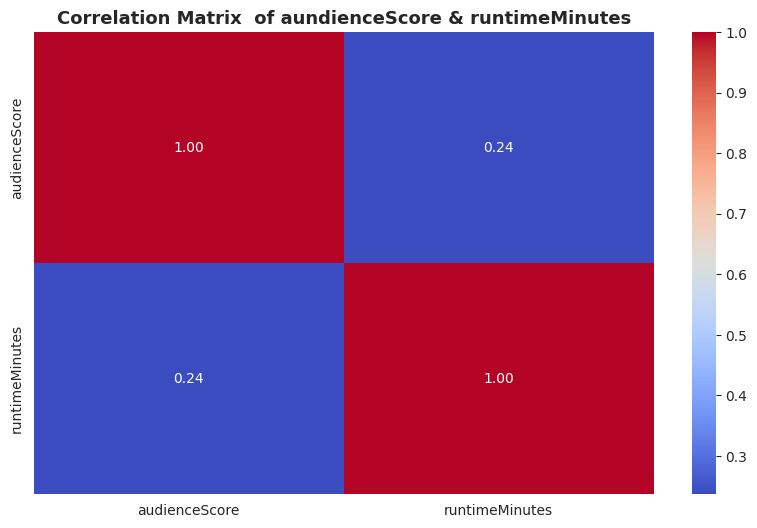

In [41]:
num_col=['audienceScore','runtimeMinutes']
corr_matrix=movies1[num_col].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix  of aundienceScore & runtimeMinutes", fontsize=13, weight='bold')
plt.show()

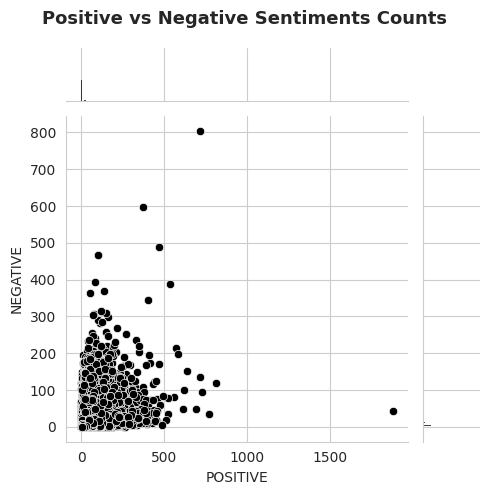

In [42]:
sentiment_counts = movies1.groupby('title')['scoreSentiment'].value_counts().unstack(fill_value=0)
sentiment_counts = sentiment_counts[['POSITIVE','NEGATIVE']]
sentiment_counts.head()
sns.jointplot(
    x='POSITIVE',
    y='NEGATIVE',
    data=sentiment_counts,
    kind='scatter',
    color='black',
    height=5
)

plt.suptitle("Positive vs Negative Sentiments Counts", fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

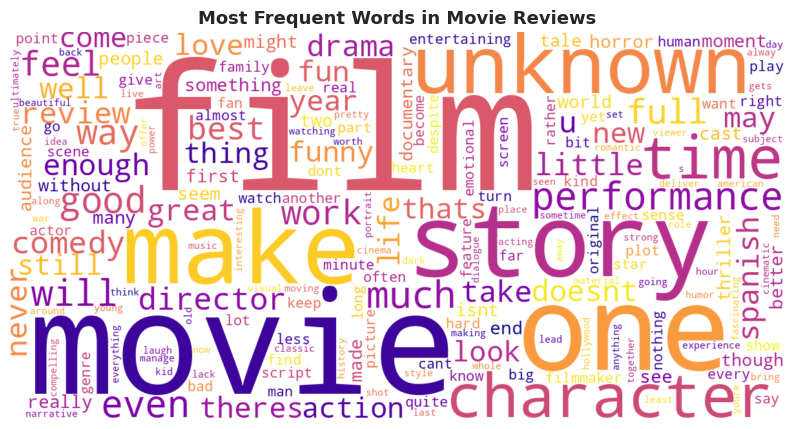

In [43]:
text= ' '.join(movies1['reviewText'].dropna().astype(str))
text = re.sub(r'[^a-zA-Z\s]', '', text.lower())
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='plasma',
    max_words=200,
    collocations=False
).generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words in Movie Reviews", fontsize=13, weight='bold')
plt.show()

In [44]:
movie_reviews = movies1.groupby('title')['reviewText'].apply(lambda x: ' '.join(x)).reset_index()

In [45]:
movie_info = movies1.drop_duplicates(subset='title')[['title', 'genre', 'runtimeMinutes', 'audienceScore', 'director']]

movies_combined = pd.merge(movie_info, movie_reviews, on='title')

In [46]:
tfidf = TfidfVectorizer(stop_words='english', max_features=3000)
tfidf_matrix = tfidf.fit_transform(movies_combined['reviewText'].fillna(''))

In [47]:
movies_combined['genre_list'] = movies_combined['genre'].fillna('').str.split(',')
mlb = MultiLabelBinarizer(sparse_output=True)
genre_matrix = mlb.fit_transform(movies_combined['genre_list'])

lb_director = LabelBinarizer(sparse_output=True)

director_matrix = lb_director.fit_transform(movies_combined['director'].fillna('Unknown'))

In [48]:
scaler = MinMaxScaler()
num_features = scaler.fit_transform(movies_combined[['runtimeMinutes', 'audienceScore']].fillna(0))
num_sparse = csr_matrix(num_features)

In [49]:
combined_features = hstack([tfidf_matrix, genre_matrix, director_matrix, num_sparse])

movie_indices = pd.Series(movies_combined.index, index=movies_combined['title']).drop_duplicates()

train_movies, test_movies = train_test_split(movies_combined, test_size=0.2, random_state=42)

test_title = test_movies.iloc[0]['title']
print("Testing recommendations for:", test_title)

# Compute cosine similarity for that test movie
idx = movie_indices[test_title]
sim_scores = cosine_similarity(combined_features[idx], combined_features).flatten()


Testing recommendations for: The Purple Plain


In [50]:
# Get top 5 most similar movies
top_indices = sim_scores.argsort()[-6:-1][::-1]
recommended_movies = movies_combined.iloc[top_indices][['title', 'genre', 'director', 'audienceScore']]
print("\nTop 5 recommended movies for:", test_title)
display(recommended_movies)

# Calculate average similarity score
avg_similarity = np.mean(sim_scores[top_indices])
print(f"\nAverage Cosine Similarity Score: {avg_similarity:.3f}")


Top 5 recommended movies for: The Purple Plain


,title,genre,director,audienceScore
1868,The San Francisco Story,Adventure,Robert Parrish,68.0
5612,Sanjuro,"Adventure, Action",Akira Kurosawa,95.0
54205,Raiders of the Lost Ark,"Adventure, Action",Steven Spielberg,96.0
26833,The Adventures of Robin Hood,"Adventure, Action","Michael Curtiz,William Keighley",89.0
37218,Uncharted,"Adventure, Action",Ruben Fleischer,90.0



Average Cosine Similarity Score: 0.580


In [52]:
# Recommendation function
def recommend(title=None, genres=None, top_n=5):
    if title:
        matches = movies_combined[movies_combined['title'].str.lower().str.contains(title.lower())]
        if matches.empty:
            return f" Movie '{title}' not found in dataset."

        idx = matches.index[0]
        sim_scores = linear_kernel(combined_features[idx], combined_features).flatten()
        sim_indices = sim_scores.argsort()[::-1]
        sim_indices = [i for i in sim_indices if i != idx][:top_n]

        recs = movies_combined.iloc[sim_indices][['title', 'genre', 'director', 'audienceScore']].copy()

        if genres:
            genres = [g.strip().lower() for g in genres.split(',')]
            recs = recs[recs['genre'].apply(lambda x: any(g in x.lower() for g in genres))]
            if recs.empty:
                return f"No matches found for title '{title}' with genres {genres}"
        return recs.reset_index(drop=True)

    elif genres:
        genres = [g.strip().lower() for g in genres.split(',')]
        filtered = movies_combined[movies_combined['genre'].apply(lambda x: any(g in x.lower() for g in genres))]
        if filtered.empty:
            return f"No movies found with genres: {genres}"
        return filtered[['title', 'genre', 'director', 'audienceScore']].head(top_n).reset_index(drop=True)
    else:
        return " Please enter either a movie title or genre(s)!"


In [53]:
from ipywidgets import interact, widgets
from IPython.display import display

# Define the text box
title_input = widgets.Text(
    value='',
    placeholder='Enter a movie name',
    description='🎬 Title:',
    disabled=False
)

genre_input = widgets.Text(
    value='',

    placeholder='Enter genres',
    description='🎭 Genre:',
    disabled=False
)

# Buttons for recommendation
button = widgets.Button(description="Get Recommendations", button_style='success')
output = widgets.Output()

display(title_input, genre_input, button, output)

def on_button_click(b):
    with output:
        output.clear_output()
        title = title_input.value.strip()
        genres = genre_input.value.strip()
        print(f"\n🎬 Recommendations based on:", end=" ")
        if title: print(f"title = '{title}'", end=" ")
        if genres: print(f"and genres = '{genres}'")
        print("\n")
        recs = recommend(title if title else None, genres if genres else None, top_n=5)
        display(recs)

button.on_click(on_button_click)

Text(value='', description='🎬 Title:', placeholder='Enter a movie name')

Text(value='', description='🎭 Genre:', placeholder='Enter genres')

Button(button_style='success', description='Get Recommendations', style=ButtonStyle())

Output()